# Pandas數據分析

今天介紹資料分析近來很紅的 pandas 套件, 作者是 Wes McKinney。Python 會成為一個數據分析的熱門語言, 和 pandas 的出現也有相當的關係。

但是 pandas 雖然功能強, 但有些地方沒那麼直覺, 有時會讓大家以為是個深奧的套件。其實你大約可以把 pandas 想成「Python 的 Excel」, 但是功能更強、更有彈性、也有更多的可能性。

下面介紹個基本上就是把 pandas 當 Excel 學的影片, 相信大家會覺得很親切。<br>
https://youtu.be/9d5-Ti6onew

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## 1 開始使用 `pandas`

首先我們來讀入一個 CSV 檔, 這裡有個「假的」學測成績, 叫 `grades.csv` 我們來練習一下。

In [22]:
import pandas as pd
df = pd.read_csv('data/grades.csv')

用 `df` 是標準的叫法 (雖然這名稱我們隨便取也可以), 意思是 Data Frame, 這是 `pandas` 兩大資料結構之一。我們可以把 Data Frame 想成一張表格 (雖然其實可以是很多張表格)。

我們來看看我們 `df` 的前五筆資料。

In [8]:
df.head()

,姓名,國文,英文,數學,自然,社會
0,劉俊安,9,10,15,10,13
1,胡玉華,10,10,10,8,9
2,黃淑婷,13,15,8,11,14
3,陳上紫,10,10,8,9,14
4,崔靜成,13,12,14,12,13


#### Excel 檔也可以快速讀入

不只 CSV 檔, 很多資料檔案, 像 Excel 檔都很容易在 `pandas` 完成。使用法是這樣:

    df2 = pd.read_excel('filename.xls', 'sheetname')
    
其中 sheetname 那裡要放工作表的名稱, 如果是中文的最好改成英文。

如果你曾經手動讀入 CSV 檔, 就知道這省了多少事 (雖然我個人還挺喜歡純手動帶進 CSV)。

## 2 Pandas 基本資料結構

Pandas 有兩個基本資料結構:

* <b style="color:red;">DataFrame</b>: 可以想成一個表格。
* <b style="color:red;">Series</b>: 表格的某一列、某一行, 基本上就是我們以前的 list 或 array

一個 DataFrame, 我們有 `index` (列的名稱), `columns` (行的名稱)。

#### DataFrame

![DataFrame 的結構](images/indexcol.png)

#### Series

剛剛說 series 大概就是一個 list, 一個 array。其實更精準的說, 其實是一個有 "index" 的 array。

DataFrame 的每一行或每一列其實也都是一個 series。我們來看個例子, 例如所有同學的國文成績, 就是一個 series。

In [9]:
df['國文']

0      9
1     10
2     13
3     10
4     13
      ..
95     9
96     8
97    14
98    15
99     9
Name: 國文, Length: 100, dtype: int64

在 Python 3 中, 我們終於可以和英文同步, 用這種很炫的方式叫出所有國文成績。

In [10]:
df.國文

0      9
1     10
2     13
3     10
4     13
      ..
95     9
96     8
97    14
98    15
99     9
Name: 國文, Length: 100, dtype: int64

#### 資料畫出來

要畫個圖很容易。

<Axes: >

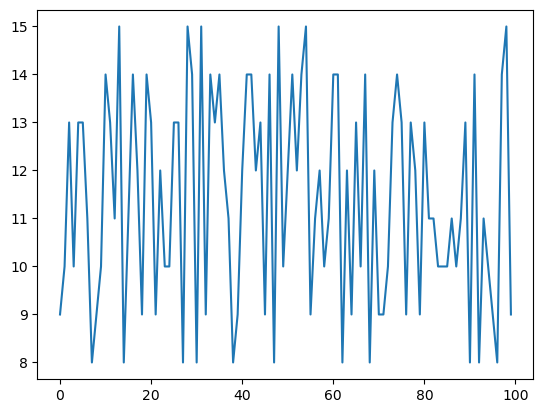

In [11]:
df.國文.plot()

當然, 在這個例子中, 其實畫 histogram 圖更有意義一點。

<Axes: >

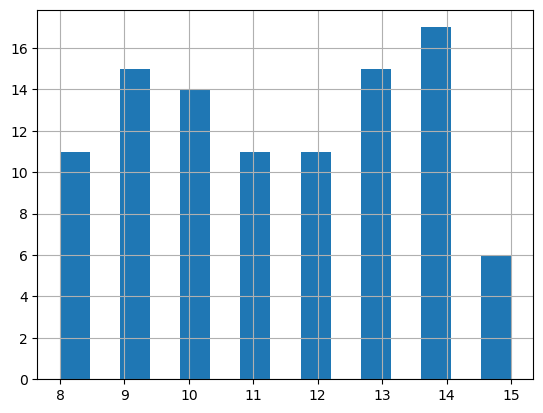

In [14]:
df.國文.hist(bins = 15)

## 3 一些基本的資料分析

算平均。

In [14]:
df.國文.mean()

np.float64(11.39)

算標準差。

In [16]:
df.國文.std()

2.1968526614594834

不如就該算的都幫我們算算...

In [17]:
df.describe()

,國文,英文,數學,自然,社會
count,100.000000,100.000000,100.000000,100.00000,100.00000
mean,11.390000,11.380000,11.570000,11.03000,11.83000
std,2.196853,2.273164,2.310516,2.21772,2.48655
min,8.000000,8.000000,8.000000,8.00000,8.00000
25%,9.000000,9.000000,10.000000,9.00000,9.00000
50%,11.000000,11.000000,11.000000,11.00000,12.00000
75%,13.000000,13.000000,14.000000,13.00000,14.00000
max,15.000000,15.000000,15.000000,15.00000,15.00000


有時我們很愛看的相關係數矩陣。

In [22]:
df.corr(numeric_only=True)

,國文,英文,數學,自然,社會
國文,1.000000,0.160158,-0.310899,-0.110236,-0.028421
英文,0.160158,1.000000,0.025656,0.113929,-0.063512
數學,-0.310899,0.025656,1.000000,0.014371,0.041651
自然,-0.110236,0.113929,0.014371,1.000000,-0.156594
社會,-0.028421,-0.063512,0.041651,-0.156594,1.000000


只算兩科間的相關係數當然也可以。

In [23]:
df.國文.corr(df.數學)

np.float64(-0.3108989822179331)

## 4 增加一行

### 【技巧】

我們增加一行, 加入總級分。

In [71]:
df['總級分'] = df.sum(axis=1, numeric_only=True)
df.head()
#預防錯誤：還記得你上一個問題提到的「劉俊安」嗎？如果你的資料表裡還有姓名等文字欄位，
#建議在 sum() 裡面加上 numeric_only=True，這樣它才會乖乖只加總數字，不會因為遇到名字又報錯喔！
#這個容易多次相加愈來愈高，要去原始讀取data，就是csv檔的那個地方，按shift+enter

,姓名,國文,英文,數學,自然,社會,加權,總級分
0,劉俊安,9,10,15,10,13,49,106
1,胡玉華,10,10,10,8,9,40,87
2,黃淑婷,13,15,8,11,14,44,105
3,陳上紫,10,10,8,9,14,36,87
4,崔靜成,13,12,14,12,13,53,117


### 【技巧】

有計算的當然也可以的。

In [37]:
df['加權'] = df.國文 + df.英文 + df.數學*2
df.head()

,姓名,國文,英文,數學,自然,社會,總級分,加權
0,劉俊安,9,10,15,10,13,57,49
1,胡玉華,10,10,10,8,9,47,40
2,黃淑婷,13,15,8,11,14,61,44
3,陳上紫,10,10,8,9,14,51,36
4,崔靜成,13,12,14,12,13,64,53


## 5 排序和 index 重設

### 【重點】排序的方法

我們依總級分來排序。

In [72]:
df.sort_values(by = '總級分', ascending=False).head(10)

,姓名,國文,英文,數學,自然,社會,加權,總級分
57,胡淳茜,12,15,14,13,11,55,120
25,蔡亦瑄,13,13,14,13,12,54,119
83,李士賢,10,14,15,13,13,54,119
36,詹威德,12,13,15,10,14,55,119
37,曾怡君,11,12,15,13,14,53,118
48,陳怡婷,15,14,12,9,15,53,118
80,施雅鈴,13,15,12,13,13,52,118
73,吳志遠,13,15,15,8,8,58,117
4,崔靜成,13,12,14,12,13,53,117
87,趙偉希,10,13,14,13,15,51,116


### 【重點】排序的方法

加權分最高, 同分才看總級分

In [68]:
df2 = df.sort_values(by = ['加權','總級分'],ascending=False)

### 【重點】重設 index

In [52]:
df2.index = range(1, 101)
df2.head()

,姓名,國文,英文,數學,自然,社會,總級分,加權
1,吳志遠,13,15,15,8,8,59,58
2,胡淳茜,12,15,14,13,11,65,55
3,詹威德,12,13,15,10,14,64,55
4,蔡亦瑄,13,13,14,13,12,65,54
5,李士賢,10,14,15,13,13,65,54


## 6 篩出我們要的資料

基本上和 NumPy 的 array 篩法很像。

### 【重點】

找出數學滿級分同學。

In [54]:
df2[df2.數學==15]

,姓名,國文,英文,數學,自然,社會,總級分,加權
1,吳志遠,13,15,15,8,8,59,58
3,詹威德,12,13,15,10,14,64,55
5,李士賢,10,14,15,13,13,65,54
7,曾怡君,11,12,15,13,14,65,53
10,林哲法,14,9,15,10,14,62,53
13,陳竹伯,10,12,15,10,14,61,52
15,葉儀依,9,13,15,8,14,59,52
18,周育霖,9,12,15,13,12,61,51
21,張雅彬,10,11,15,12,8,56,51
22,芮秋辛,11,10,15,10,8,54,51


### 【重點】

找出數學和英文都滿級分的同學。要注意 `and` 要用 `&`, `or` 要用 `|`。每個條件一定要加弧號。

In [59]:
df2[(df2.數學==15) & (df2.英文==15)]

,姓名,國文,英文,數學,自然,社會,總級分,加權
1,吳志遠,13,15,15,8,8,59,58


## 7 刪除一行或一列

### 【重點】刪掉一行

我們來刪掉總級分的那行。

In [73]:
df.drop('總級分',axis=1,inplace=True)
df

,姓名,國文,英文,數學,自然,社會,加權
0,劉俊安,9,10,15,10,13,49
1,胡玉華,10,10,10,8,9,40
2,黃淑婷,13,15,8,11,14,44
3,陳上紫,10,10,8,9,14,36
4,崔靜成,13,12,14,12,13,53
...,...,...,...,...,...,...,...
95,蔡佳燕,9,10,9,13,14,37
96,吳筱婷,8,10,14,10,15,46
97,陳家銘,14,9,11,8,12,45
98,李明威,15,9,8,9,15,40


### 【重點】改變原有的 DataFrame

我們會發現 `pandas` 很多動作都沒有更改原有的 DataFrame, 真的要改要加入

    inplace=True

In [74]:
df2.drop('總級分',axis=1,inplace=True)
df2

,姓名,國文,英文,數學,自然,社會,加權
73,吳志遠,13,15,15,8,8,58
57,胡淳茜,12,15,14,13,11,55
36,詹威德,12,13,15,10,14,55
25,蔡亦瑄,13,13,14,13,12,54
83,李士賢,10,14,15,13,13,54
...,...,...,...,...,...,...,...
3,陳上紫,10,10,8,9,14,36
84,胡凱琳,10,8,9,9,15,36
32,林建亨,9,11,8,8,11,36
18,梁慧君,9,8,8,8,12,33


### 【重點】刪掉一列

刪掉列就是指定要刪去的 index。

In [76]:
df2.drop(5).head()
df

,姓名,國文,英文,數學,自然,社會,加權
0,劉俊安,9,10,15,10,13,49
1,胡玉華,10,10,10,8,9,40
2,黃淑婷,13,15,8,11,14,44
3,陳上紫,10,10,8,9,14,36
4,崔靜成,13,12,14,12,13,53
...,...,...,...,...,...,...,...
95,蔡佳燕,9,10,9,13,14,37
96,吳筱婷,8,10,14,10,15,46
97,陳家銘,14,9,11,8,12,45
98,李明威,15,9,8,9,15,40


,姓名,國文,英文,數學,自然,社會,加權
1,吳志遠,13,15,15,8,8,58
2,胡淳茜,12,15,14,13,11,55
3,詹威德,12,13,15,10,14,55
4,蔡亦瑄,13,13,14,13,12,54
6,童心怡,13,13,14,8,13,54


### 【重點】刪掉一列

通常刪掉符合條件的比較合理 (注意是找到要刪掉的部份, 再找出相對的 index)。

In [77]:
df2.drop(df2[df2.姓名=='李士賢'].index)

,姓名,國文,英文,數學,自然,社會,加權
73,吳志遠,13,15,15,8,8,58
57,胡淳茜,12,15,14,13,11,55
36,詹威德,12,13,15,10,14,55
25,蔡亦瑄,13,13,14,13,12,54
44,童心怡,13,13,14,8,13,54
...,...,...,...,...,...,...,...
3,陳上紫,10,10,8,9,14,36
84,胡凱琳,10,8,9,9,15,36
32,林建亨,9,11,8,8,11,36
18,梁慧君,9,8,8,8,12,33


## 8 真實股價資料

有個從 `Pandas` 獨立出來的套件叫 `pandas-datareader`, 幾經波折, 先是 Yahoo! 的財務資料不能用, 後來又是 Google 的資料不能用, 不過至少現在看來 Yahoo! 還可以使用。

安裝 `pandas-datareader` 就標準 `conda` 安裝:

    conda install pandas-datareader
    
如果裝過, 但很久沒更新就用:

    conda update pandas-datareader

### 【例子】 分析 Apple 股價

In [91]:
import yfinance as yf

# 直接下載蘋果 (AAPL) 的資料
df = yf.download('AAPL', start='2025-05-01', end='2026-05-01')
print(df.head())

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2025-05-01  212.394302  213.628912  207.993470  208.172696   57365700
2025-05-02  204.458893  206.091775  201.282733  205.195672  101010600
2025-05-05  198.026917  203.214314  197.349875  202.218654   69018500
2025-05-06  197.648544  199.779257  196.165020  197.349858   51216500
2025-05-07  195.398376  198.574536  192.411395  198.305703   68536700


In [2]:
# 為防止網路有問題, 我們把這個檔案以 aapl.csv 存起來, 可以這樣讀入。
# df = pd.read_csv('data/aapl.csv', index_col="Date")

#### 只要最後 300 個交易日!

In [92]:
df = df[-300:]
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-05-01,212.394302,213.628912,207.993470,208.172696,57365700
2025-05-02,204.458893,206.091775,201.282733,205.195672,101010600
2025-05-05,198.026917,203.214314,197.349875,202.218654,69018500
2025-05-06,197.648544,199.779257,196.165020,197.349858,51216500
2025-05-07,195.398376,198.574536,192.411395,198.305703,68536700
...,...,...,...,...,...
2026-04-24,271.059998,273.059998,269.649994,272.760010,38157100
2026-04-27,267.609985,268.359985,265.070007,266.089996,41466800


#### 20 日的移動平均

<Axes: xlabel='Date'>

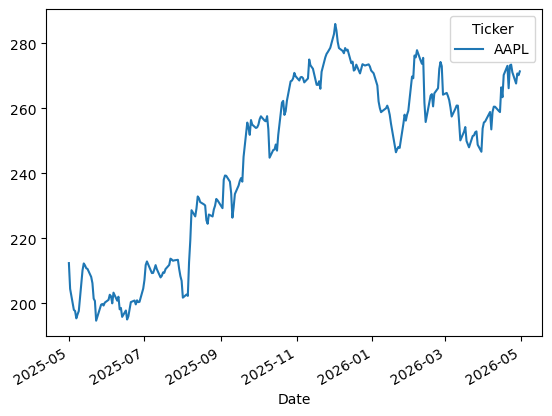

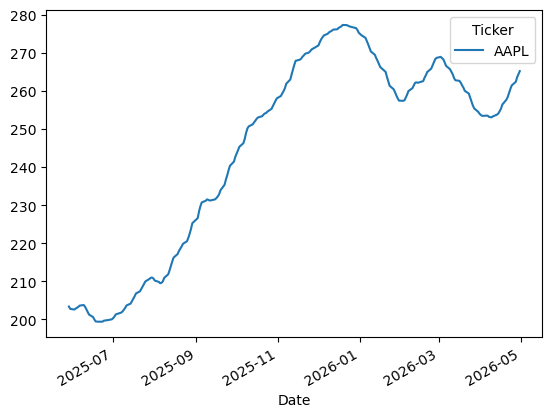

In [95]:
df.Close.plot()
df.Close.rolling(20).mean().plot()

#### 20 日和 60 日的移動平均

<Axes: xlabel='Date'>

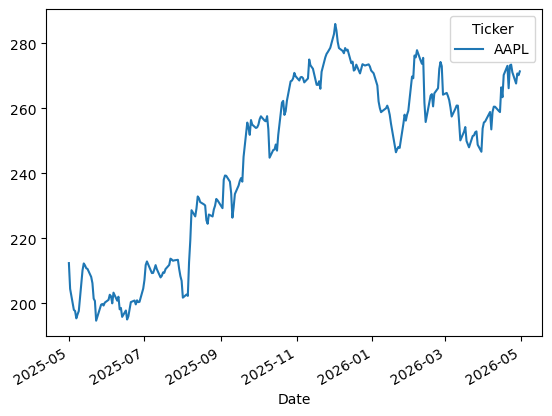

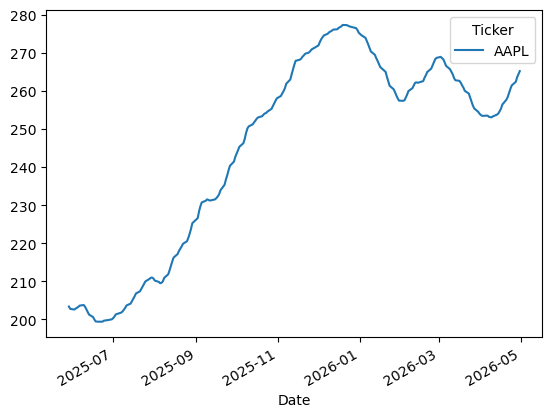

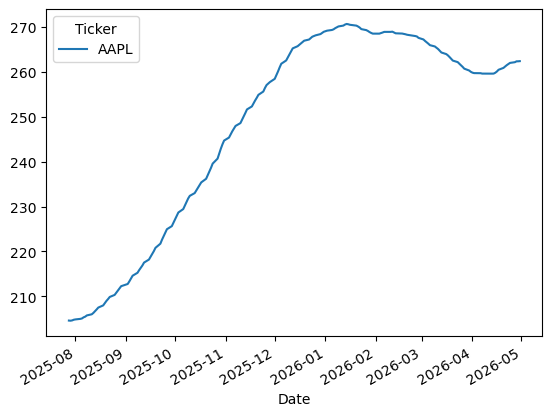

In [96]:
df.Close.plot(legend=True)
df.Close.rolling(20).mean().plot(label="$MA_{20}$",legend=True)
df.Close.rolling(60).mean().plot(label="$MA_{60}$",legend=True)

#### 準備做預測

我們用個非常天真的模型...

![天真股票模型](images/naive.png)

網路上說這是線性的 (可能嗎)!


In [97]:
close = df.Close.values
len(close)

251

In [98]:
x = close[:-1]
len(x)

250

In [99]:
y = close[1:]
len(y)

250

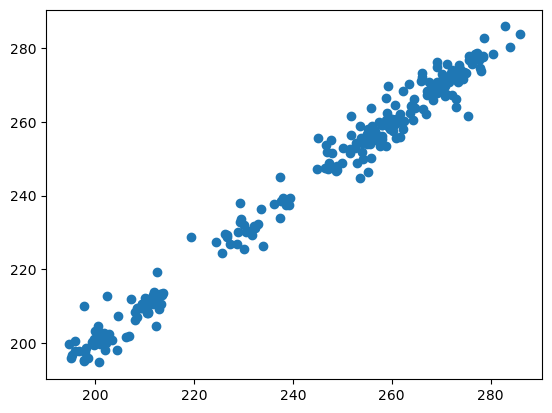

In [102]:
import matplotlib.pyplot as plt
plt.scatter(x,y)

哦, 真的有點像線性的, 我們之後用線性迴歸試試看。

## 9 手工打造一個 DataFrame*

有時我們用手工打造一個簡單的 DataFrame, 可以更理解整個結構。其實很容易, 一個 DataFrame 基本上就包含兩個主要部份:

* 資料本身: 通常一個二維陣列 (矩陣)
* 行、列的名稱

我們來個簡單的小例子。

In [10]:
mydata = np.random.randn(4,3)
mydata

[[ 1.64023577  0.58916514 -0.65570395]
 [-0.91344442 -0.14838053 -0.12640818]
 [-0.58410055  0.05855468  0.78535437]
 [-0.11701249 -0.22845015 -0.79071129]]


把行列的名字放進去, 就成一個 DataFrame。我們列的部份先讓 Python 自己產生。

In [18]:
df2 = pd.DataFrame(mydata, columns=list("ABC"))
df2

,A,B,C
0,1.640236,0.589165,-0.655704
1,-0.913444,-0.148381,-0.126408
2,-0.584101,0.058555,0.785354
3,-0.117012,-0.228450,-0.790711


In [19]:
df3 = pd.DataFrame(np.random.randn(3,3), columns=list("ABC"))
df3

,A,B,C
0,0.012175,1.693264,-0.557278
1,-2.216244,1.353252,0.039766
2,0.476420,0.344540,-0.133643


#### 兩個表格上下貼起來

我們再來生一個 DataFrame, 再「貼」起來。

In [20]:
df4 = pd.concat([df2,df3],axis=0)
df4

,A,B,C
0,1.640236,0.589165,-0.655704
1,-0.913444,-0.148381,-0.126408
2,-0.584101,0.058555,0.785354
3,-0.117012,-0.228450,-0.790711
0,0.012175,1.693264,-0.557278
1,-2.216244,1.353252,0.039766
2,0.476420,0.344540,-0.133643


前面我們弄得亂七八糟的 index 重設一下。

In [21]:
df4.index = range(7)

,A,B,C
0,-2.552313,1.906824,-0.201567
1,1.017096,-0.032225,-0.379340
2,-0.251371,1.026546,2.267663
3,-0.068840,-0.611686,0.174140
4,-0.171660,1.542380,2.685066
5,0.786684,-1.182996,0.401870
6,-2.216455,0.299553,-1.112735


#### 横向的貼

等等, 這大小好像不太對也可以嗎? 答案是可以的!

In [22]:
df5 = pd.concat([df2,df3],axis=1)
df5

,A,B,C,A,B,C
0,1.640236,0.589165,-0.655704,0.012175,1.693264,-0.557278
1,-0.913444,-0.148381,-0.126408,-2.216244,1.353252,0.039766
2,-0.584101,0.058555,0.785354,0.476420,0.344540,-0.133643
3,-0.117012,-0.228450,-0.790711,NaN,NaN,NaN


#### 大一點的例子

我們來做前面「假的」學測資料。首先要有「假的」同學名單, 如果有興趣產生很多名字, 可以用這個服務。

[中文姓名產生器](http://www.richyli.com/name/index.asp)

In [29]:
df_names = pd.read_csv('data/names.csv',names=['姓名'])
df_names.head()

,姓名
0,羅雅慧
1,王紹尹
2,黃季坤
3,許正書
4,張鈞蓮


In [27]:
df_grades = pd.DataFrame(np.random.randint(6,16,(100,5)),
                        columns=['國文','英文','數學','社會','自然'])
df_grades

,國文,英文,數學,社會,自然
0,8,8,14,15,14
1,7,7,15,8,12
2,9,14,15,13,13
3,11,14,6,11,11
4,9,8,15,15,14
...,...,...,...,...,...
95,7,11,8,13,10
96,9,13,15,8,13
97,10,8,15,14,11
98,10,7,11,8,14


In [31]:
df_grades.to_csv('data/grades2.csv',index=0)

In [33]:
df_x = pd.concat([df_names,df_grades],axis=1)
df_x

,姓名,國文,英文,數學,社會,自然
0,羅雅慧,8,8,14,15,14
1,王紹尹,7,7,15,8,12
2,黃季坤,9,14,15,13,13
3,許正書,11,14,6,11,11
4,張鈞蓮,9,8,15,15,14
...,...,...,...,...,...,...
95,陳君生,7,11,8,13,10
96,曾桂甫,9,13,15,8,13
97,林欣怡,10,8,15,14,11
98,林佳霖,10,7,11,8,14
